In [1]:
import numpy as np
import torch
import crsData as crs
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

%matplotlib inline

In [2]:
import crossSections as cross
filename = './crs/BSR.txt'
BSR = cross.multipleCrossSections(filename)
filename = './crs/IST-Lisbon.txt'
IST = cross.multipleCrossSections(filename)

# datasets
datasets = ["Biagi","BSR","Hayashi","IST-Lisbon","Morgan","Phelps","Puech","SIGLO","TRINITI"]
Nsets = len(datasets)

In [3]:
refs = ['Chutjian1981','Buckman1983','Filipovic2000b','Khakoo2004','Tsurubuchi1996','Schappe1994','Li1988','Rapp1965','Straub1995','Wetzel1987','Mielewska2004','Panajotovic1997','Gibson1996','Srivastava1981']
Nrefs = len(refs)
swarms, idx = [], 0
for ref in refs:
#     if (ref=='Tsurubuchi1996'):
#         continue
    filename = '../crs-exp/%s.txt' % ref
    swarms.append( crs.crsData(filename) )
    print(swarms[idx].ref)
    print(swarms[idx].variables)
    for dataType, dataset in swarms[idx].datasets.items():
        print(crs.typeDictI2S[dataType])
        print(dataset.variables)
        print(dataset.data)
    idx += 1


Chutjian, A., & Cartwright, D. C. (1981). Electron-impact excitation of electronic states in argon at incident energies between 16 and 100 eV. Physical Review A, 23(5), 2178–2193. https://doi.org/10.1103/PhysRevA.23.2178
{'E': ['eV', 'n/a', 'n/a'], 'crs': ['cm2', 'n/a', 'n/a'], 'crs-rms': ['%', 'n/a', 'n/a']}
Excitation, level 1
['E', 'crs', 'crs-rms']
[[1.60e+01 4.19e-18 2.90e+01]
 [2.00e+01 3.19e-18 2.90e+01]
 [3.00e+01 1.66e-18 2.90e+01]
 [5.00e+01 3.61e-19 3.30e+01]
 [1.00e+02 5.60e-20 4.70e+01]]
Excitation, level 2
['E', 'crs', 'crs-rms']
[[1.60e+01 3.97e-18 2.90e+01]
 [2.00e+01 3.70e-18 2.90e+01]
 [3.00e+01 4.56e-18 2.90e+01]
 [5.00e+01 5.78e-18 2.90e+01]
 [1.00e+02 3.28e-18 2.90e+01]]
Excitation, level 3
['E', 'crs', 'crs-rms']
[[1.60e+01 6.09e-19 3.30e+01]
 [2.00e+01 6.44e-19 3.30e+01]
 [3.00e+01 4.54e-19 4.70e+01]
 [5.00e+01 1.12e-19 4.70e+01]
 [1.00e+02 5.41e-20 4.70e+01]]
Excitation, level 4
['E', 'crs', 'crs-rms']
[[1.60e+01 8.53e-18 2.90e+01]
 [2.00e+01 1.00e-17 2.90e+01]


Chutjian, A., & Cartwright, D. C. (1981). Electron-impact excitation of electronic states in argon at incident energies between 16 and 100 eV. Physical Review A, 23(5), 2178–2193. https://doi.org/10.1103/PhysRevA.23.2178
16.0
Khakoo, M. A., Vandeventer, P., Childers, J. G., Kanik, I., Fontes, C. J., Bartschat, K., Zeman, V., Madison, D. H., Saxena, S., Srivastava, R., & Stauffer, A. D. (2004). Electron impact excitation of the argon 3p54s configuration: Differential cross-sections and cross-section ratios. Journal of Physics B: Atomic, Molecular and Optical Physics, 37(1), 247–281. https://doi.org/10.1088/0953-4075/37/1/016
14.0
Tsurubuchi, S., Miyazaki, T., & Motohashi, K. (1996). Electron-impact emission cross sections of Ar. Journal of Physics B: Atomic, Molecular and Optical Physics, 29(9), 1785–1801. https://doi.org/10.1088/0953-4075/29/9/022
15.071227991895011
Li, G. P., Takayanagi, T., Wakiya, K., Suzuki, H., Ajiro, T., Yagi, S., Kano, S. S., & Takuma, H. (1988). Determination o

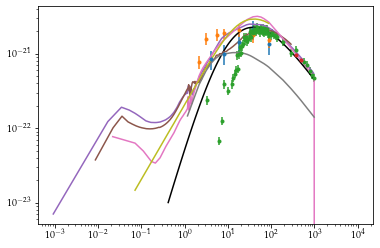

In [4]:
from models import *
dataType = crs.typeDictS2I['Excitation, level 4']

# W = None
W = []
for k, swarm in enumerate(swarms):
    if dataType in swarm.datasets:
        print(swarm.ref)
        temp = np.copy(swarm.datasets[dataType].data)
        var1 = swarm.datasets[dataType].variables[1]

        if ( swarm.variables[var1][0] == 'cm2' ):
            temp[:,1] *= 1e-4
            
        if (swarm.variables[var1][1]!='n/a'):
            error = temp[:,1][...,None] * 1e-2 * crs.readNumber(swarm.variables[var1][1][:-1])
            temp = np.append( temp, error, axis=1)
        elif (swarm.variables[var1][2]!='n/a'):
            error = temp[:,1][...,None] * 1e-2 / 3.0 * crs.readNumber(swarm.variables[var1][2][:-1])
            temp = np.append( temp, error, axis=1)
        else:
            var2 = swarm.datasets[dataType].variables[2]
            if ( swarm.variables[var2][0] == '%' ):
                temp[:,2] *= 1e-2 * temp[:,1]
            elif ( swarm.variables[var2][0] == 'cm2' ):
                temp[:,2] *= 1e-4
            if ( var2[-3:] == 'max' ):
#                 temp[:,2] *= 1.0
                temp[:,2] *= 1.0 / 3.0
        print(temp[0,0])
        W += [temp]
#         if (W is None):
#             W = np.copy(temp)
#         else:
#             W = np.append( W, temp, axis=0)

#         filename = '../crs-exp/excitation-level4/crs.%s.txt' % (refs[k])
#         np.savetxt(filename,temp,fmt='%.15E',delimiter=' ')
        
# Include BSR dataset, except the first entry (excitation level).
for c in BSR.crs:
    if ((c.colType==2) and (c.deltaE>11.8) and (c.deltaE<11.9)):
        temp = np.copy(c.data[1:,:])
        error = temp[:,1][...,None] * 5.0
        temp = np.append( temp, error, axis=1)
        print(c.deltaE)
        print(np.count_nonzero(np.logical_and((temp[:,0]-E_ext[3]>np.exp(1)), (temp[:,0]-E_ext[3]<np.exp(3)))))
#         W += [temp]
#         W = np.append( W, temp, axis=0)

for c in IST.crs:
    if ((c.colType==2) and (c.deltaE>11.8) & (c.deltaE<11.9)):
        temp1 = np.copy(c.data[1:,:])
        error = temp1[:,1][...,None] * 0.01
        temp1 = np.append( temp1, error, axis=1)
        print(c.deltaE)

# mask = W[:,0] - E_ext[3] < 15.0
# W = W[mask,:]
# W = W[-1]
    
E4 = 11.82
theta_ref = np.array([2.54e0,1])
Etest = np.linspace(-3.,3.,200)
Etest = 10.0 ** Etest + E_ext[3]
model0 = Excite_resonance(4,theta_ref,Etest)
mask = model0 > 1.0e-23
# Etest = Etest[mask]
# model0 = model0[mask]
plt.figure(1)
for Wk in W:
    plt.errorbar(Wk[:,0]-E4,Wk[:,1],yerr=Wk[:,2],fmt='.')
# plt.errorbar(W[:,0]-E_ext[3],W[:,1],yerr=W[:,2],fmt='.')
# plt.loglog(temp[:,0]-E_ext[3],temp[:,1],'-r')
# plt.loglog(temp1[:,0]-E_ext[3],temp1[:,1],'-r')
plt.plot(Etest[mask]-E_ext[3],model0[mask],'-k')
plt.xscale('log')
plt.yscale('log')

h = []
for k, dataset in enumerate(datasets[:-2]):
    filename = "./crs/%s.txt" % dataset
    tmp = cross.multipleCrossSections(filename)

    for c in tmp.crs:
        if ((c.colType==2) and (c.deltaE>11.8) and (c.deltaE<11.9)):
            targetmf = np.copy(c.data[1:,:])
            plt.loglog(targetmf[:,0] - E_ext[3],targetmf[:,1],'-')
            h += [dataset]

torch.Size([14, 3])


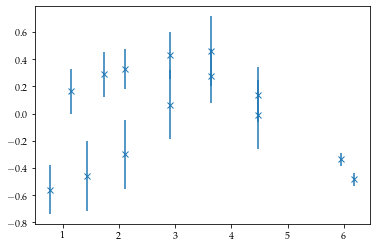

In [113]:
Wlog = []
for Wk in W:
    temp = np.copy(Wk)
    temp[:,0] = np.log(temp[:,0] - E_ext[3])
    temp[:,2] = np.log(1.0 + temp[:,2] / temp[:,1])
    temp[:,1] = np.log(temp[:,1])
    Wlog += [torch.Tensor(temp)]

Wlog = Wlog[:2] + Wlog[3:]
    
Wlogm, Nw = 0.0, 0
for wlogk in Wlog:
    Nw += wlogk.size(0)
    Wlogm += wlogk[:,1].sum()
Wlogm /= Nw

for wlogk in Wlog:
    wlogk[:,1] -= Wlogm
    
for k, wlogk in enumerate(Wlog):
    if(k==0):
        wlogx = torch.clone(wlogk[:,0])
        wlogy = torch.clone(wlogk[:,1])
        wloge = torch.clone(wlogk[:,2])
        wlogt = torch.clone(wlogk)
    else:
        wlogx = torch.cat((wlogx,wlogk[:,0]),-1)
        wlogy = torch.cat((wlogy,wlogk[:,1]),-1)
        wloge = torch.cat((wloge,wlogk[:,2]),-1)
        wlogt = torch.cat((wlogt,wlogk),0)

print(wlogt.size())
Wlog = [wlogt]
        
plt.figure(1)
for wlogk in Wlog:
    plt.errorbar(wlogk[:,0],wlogk[:,1],yerr=wlogk[:,2],fmt='x')

In [114]:
xd, yd, ed = [], [], []
xm = []
for wlogk in Wlog:
    temp = wlogk[:,0].repeat(wlogk.size(0),1)
    xd += [temp - temp.t()]
#     xm += [0.5*temp + 0.5*temp.t()]
    xm += [wlogk[:,0]]
    
    yd += [wlogk[:,1]]
    ed += [wlogk[:,2]]

class ExpKernel(torch.nn.Module):
    def __init__(self):
        """
        In the constructor we instantiate four parameters and assign them as
        member parameters.
        """
        super().__init__()
        self.var = torch.nn.Parameter(1.0 + 0.1 * torch.randn(()))
        self.scale = torch.nn.Parameter(1.0 + 0.1 * torch.randn(()))
        self.var.clamp(min=0.0)
        self.scale.clamp(min=0.0)

    def forward(self, xd):
        """
        In the forward function we accept a Tensor of input data and we must return
        a Tensor of output data. We can use Modules defined in the constructor as
        well as arbitrary operators on Tensors.
        """
        return self.var * torch.exp( - xd ** 2 / self.scale )
    
    def covariance(self, x1, x2):
        assert((x1.dim()==1) and (x2.dim()==1))
        xd = x1.repeat(x2.size(0),1).t() - x2.repeat(x1.size(0),1)
        return self.var * torch.exp( - xd ** 2 / self.scale )
    
class ExpTanhKernel(torch.nn.Module):
    def __init__(self):
        """
        In the constructor we instantiate four parameters and assign them as
        member parameters.
        """
        super().__init__()
        self.var = torch.nn.Parameter(1.0 + 0.1 * torch.randn(()))
        self.scale = torch.nn.Parameter(1.0 + 0.1 * torch.randn(()))
        self.var1 = torch.nn.Parameter(1.0 + 0.1 * torch.randn(()))
        self.var2 = torch.nn.Parameter(1.0 + 0.1 * torch.randn(()))
        self.slope = torch.nn.Parameter(1.0 + 0.1 * torch.randn(()))
        self.phase = torch.nn.Parameter(1.0 + 0.1 * torch.randn(()))
        self.var.clamp(min=0.0)
        self.var1.clamp(min=0.0)
        self.var2.clamp(min=0.0)
        self.scale.clamp(min=0.0)
        self.slope.clamp(min=-2.0,max=2.0)

    def forward(self, xd, xm):
        """
        In the forward function we accept a Tensor of input data and we must return
        a Tensor of output data. We can use Modules defined in the constructor as
        well as arbitrary operators on Tensors.
        """
        TanhFactor = 0.5 * (self.var1 + self.var2) + 0.5 * (self.var2 - self.var1) * torch.tanh( self.slope * (xm - self.phase) )
        return self.var * torch.exp( - xd ** 2 / self.scale ) + torch.diag(TanhFactor)
#         return self.var * torch.exp( - xd ** 2 / self.scale ) * TanhFactor
    
    def covariance(self, x1, x2):
        assert((x1.dim()==1) and (x2.dim()==1))
        xx1 = x1.repeat(x2.size(0),1).t()
        xx2 = x2.repeat(x1.size(0),1)
        xd = xx1 - xx2
#         xm = 0.5 * (xx1 + xx2)
        xm = torch.clone(xx1)
        xm[xx1!=xx2] = 0.0
        TanhFactor = 0.5 * (self.var1 + self.var2) + 0.5 * (self.var2 - self.var1) * torch.tanh( self.slope * (xm - self.phase) )
        temp = self.var * torch.exp( - xd ** 2 / self.scale )
        print(temp.size(),TanhFactor.size())
        return self.var * torch.exp( - xd ** 2 / self.scale ) + torch.diag(TanhFactor)
#         return self.var * torch.exp( - xd ** 2 / self.scale ) * TanhFactor
    
def logLikelihood(kernel):
    lk = 0.0
    
    for k in range(len(Wlog)):
        cov = kernel.forward(xd[k])
#         cov = kernel.forward(xd[k],xm[k])
        cov += torch.diag(ed[k]**2)
#         print(cov)
        Lcov = torch.cholesky(cov)
        cov_inv_y = torch.cholesky_solve(yd[k].reshape(yd[k].size(0),1),Lcov).reshape(-1)
        lk += - 0.5 * torch.dot(yd[k],cov_inv_y) - torch.sum(torch.log(torch.diagonal(Lcov))) - 0.5 * xd[k].size(0) * np.log(2.0*np.pi)
    return - lk
        

In [115]:
cov_kern = ExpKernel()
# cov_kern = ExpTanhKernel()

optimizer = torch.optim.LBFGS(cov_kern.parameters(),lr=1e-3)

def closure():
    lk = logLikelihood(cov_kern)
    optimizer.zero_grad()
    lk.backward()
    return lk

for t in range(1000):

    # Compute and print loss.
    lk = logLikelihood(cov_kern)
    if t % 100 == 99:
        print(t, lk.item())

    # Before the backward pass, use the optimizer object to zero all of the
    # gradients for the variables it will update (which are the learnable
    # weights of the model). This is because by default, gradients are
    # accumulated in buffers( i.e, not overwritten) whenever .backward()
    # is called. Checkout docs of torch.autograd.backward for more details.
    optimizer.zero_grad()

    # Backward pass: compute gradient of the loss with respect to model
    # parameters
    lk.backward()

    # Calling the step function on an Optimizer makes an update to its
    # parameters
    optimizer.step(closure)

99 5.488709449768066
199 5.405126571655273
299 5.4030046463012695
399 5.402935028076172
499 5.402895927429199
599 5.402875900268555
699 5.402871131896973
799 5.402849197387695
899 5.402840614318848
999 5.402835845947266
1099 5.402829170227051
1199 5.402813911437988
1299 5.402810096740723
1399 5.402803421020508
1499 5.402793884277344
1599 5.4027910232543945
1699 5.402782440185547
1799 5.402772903442383
1899 5.402773857116699
1999 5.4027605056762695


In [126]:
# temp = Wlog[0][:,0].repeat(Wlog[1][:,0].size(0),1)
# temp2 = Wlog[1][:,0].repeat(Wlog[0][:,0].size(0),1)
# print(Wlog[0][:,0].size())
# print(temp.t())
# print(temp2)
# wlogx = torch.cat((Wlog[0][:,0],Wlog[1][:,0]),-1)
# print(wlogx)

xtest = torch.linspace(0,7,50)
xx1 = xtest.repeat(xtest.size(0),1).t()
xt2 = xtest.repeat(xtest.size(0),1)
xtt = torch.clone(xx1)
xtt[xx1!=xt2] = 0.0
print(xtt)
print(xx1-xt2)

xtest, tmpidx = wlogx.sort()

tensor([[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.1429, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.2857,  ..., 0.0000, 0.0000, 0.0000],
        ...,
        [0.0000, 0.0000, 0.0000,  ..., 6.7143, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 6.8571, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 7.0000]])
tensor([[ 0.0000, -0.1429, -0.2857,  ..., -6.7143, -6.8571, -7.0000],
        [ 0.1429,  0.0000, -0.1429,  ..., -6.5714, -6.7143, -6.8571],
        [ 0.2857,  0.1429,  0.0000,  ..., -6.4286, -6.5714, -6.7143],
        ...,
        [ 6.7143,  6.5714,  6.4286,  ...,  0.0000, -0.1429, -0.2857],
        [ 6.8571,  6.7143,  6.5714,  ...,  0.1429,  0.0000, -0.1429],
        [ 7.0000,  6.8571,  6.7143,  ...,  0.2857,  0.1429,  0.0000]])


torch.Size([14, 14]) torch.Size([14, 14])
tensor([0.0135, 0.0078, 0.0060, 0.0054, 0.0057, 0.0057, 0.0068, 0.0068, 0.0082,
        0.0082, 0.0094, 0.0094, 0.0012, 0.0013], grad_fn=<DiagBackward0>)
torch.Size([14])
Parameter containing:
tensor(0.2765, requires_grad=True) Parameter containing:
tensor(9.4047, requires_grad=True)


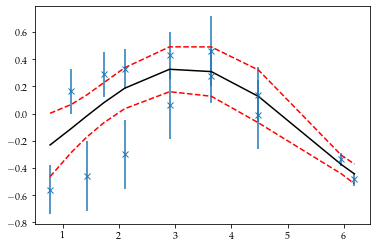

In [127]:
Kd = []
for k in range(len(Wlog)):
    cov = cov_kern.forward(xd[k])
#     cov = cov_kern.forward(xd[k],xm[k])
    cov += torch.diag(ed[k]**2)
    Kd += [cov]
Kb = torch.block_diag(*Kd)
Kp = cov_kern.covariance(wlogx,xtest)
print(Kb.size(),Kp.size())

LKb = torch.cholesky(Kb)
ym = torch.matmul( Kp.t(), torch.cholesky_solve(wlogy.reshape(wlogy.size(0),1),LKb) ).squeeze()
y_cov = cov_kern.covariance(xtest,xtest) - torch.matmul( Kp.t(), torch.cholesky_solve(Kp,LKb) )
y_var = torch.diag(y_cov)
print(y_var)
print((ym + torch.sqrt(y_var)).size())
print(cov_kern.var,cov_kern.scale)
# print(cov_kern.var1,cov_kern.var2,cov_kern.slope,cov_kern.phase)

plt.figure(1)
for wlogk in Wlog:
    plt.errorbar(wlogk[:,0],wlogk[:,1],yerr=wlogk[:,2],fmt='x')
plt.plot(xtest,ym.detach(),'-k')
plt.plot(xtest,(ym + 2.0 * torch.sqrt(y_var)).detach(),'--r')
plt.plot(xtest,(ym - 2.0 * torch.sqrt(y_var)).detach(),'--r')